Colab de referência: https://colab.research.google.com/drive/13J8VuT8tDkdazsZa4w36h_tj3Z5QuVuI


## Tipos de Regressão
Existem vários tipos de modelos de regressão, cada um com suas características e aplicações específicas:
- **Regressão Linear:** Simples e múltipla, modela a relação linear entre variáveis. É o ponto de partida para muitos estudos de regressão.
- **Regressão Ridge, Lasso e Elastic Net:** Incorporam penalizações para lidar com multicolinearidade e reduzir a complexidade do modelo, prevenindo sobreajuste.
- **Árvores de Regressão:** As árvores de regressão são uma técnica de aprendizado de máquina que utiliza uma estrutura em forma de árvore para modelar a relação entre uma variável dependente contínua e uma ou mais variáveis independentes.
- **RNN (Recurrent Neural Network) ou Rede Neural Recorrente:** é um tipo de arquitetura de rede neural projetada para processar sequências de dados. Suas principais características são: a existência de loops internos que permitem que informações persistam; sua capacidade de lidar com entradas e saídas de comprimento variável; o compartilhamento de parâmetros ao longo do tempo, reduzindo o número total de parâmetros a serem aprendidos. Especialmente útil para tarefas que envolvem dados sequenciais, como processamento de linguagem natural, reconhecimento de fala e previsão de séries temporais.

### Regressão Linear

- **Definição:** A regressão linear é um método estatístico para modelar a relação entre uma variável dependente e uma ou mais variáveis independentes assumindo uma relação linear.
- **Fórmula:** $ y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_n x_n + \epsilon $
- **Interpretação:** Utilizada quando se espera que a variável dependente varie linearmente com as variáveis independentes.
### Explicação Detalhada da Regressão Linear

A regressão linear simples assume a seguinte fórmula:

$ y = \beta_0 + \beta_1 X + \epsilon $

onde:
- $ y $ é a variável dependente.
- $ X $ é a variável independente.
- $ \beta_0 $ é o intercepto (valor de $ y $ quando $ X = 0 $).
- $ \beta_1 $ é o coeficiente de inclinação (quanto $ y $ muda com uma unidade de mudança em $ X $).
- $ \epsilon $ é o termo de erro (a diferença entre os valores observados e os valores preditos).

#### Exemplo - Aplicação da Regressão Linear

Nesse exemplo é proposta a criação de um modelo linear para ser possível predizer qual seria o valor esperado de produção de uma máquina conforme fosse o ajuste de sua velocidade de produção.
- Em $X$ temos a velocidade de produção de uma máquina
- Em $y$ temos a quantidade de produtos produzidos

Passo 1: Carregamento dos dados

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Gerar dados aleatórios
np.random.seed(42)
X = 2 * np.random.rand(10, 1)
# Ordena os dados de X
X = sorted(X)
# Adequa o formato
X = np.array([arr.tolist() for arr in X])

# Cria os valores de y observados
y = 4 + 3 * X + np.random.randn(10, 1)

Passo 2: Plotagem dos dados

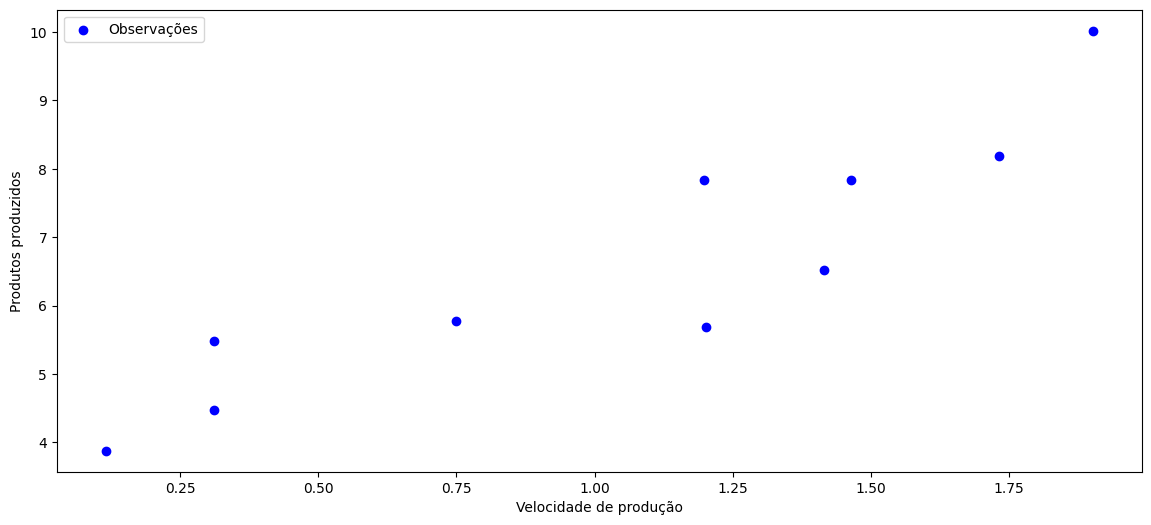

In [2]:
fig, axs = plt.subplots(1, 1, figsize=(14, 6))
axs.scatter(X,y, color='blue', label='Observações')
# Adiciona a legenda
plt.legend()
# Adiciona rótulos dos eixos
plt.xlabel("Velocidade de produção")
plt.ylabel("Produtos produzidos")
plt.show()

Passo 3: Testa-se um modelo simples

Um primeiro modelo mais intuitivo é encontrar a média dos valores e adotar esse como se fosse o modelo.

Médias dos valores de produção é 6.569503524584387


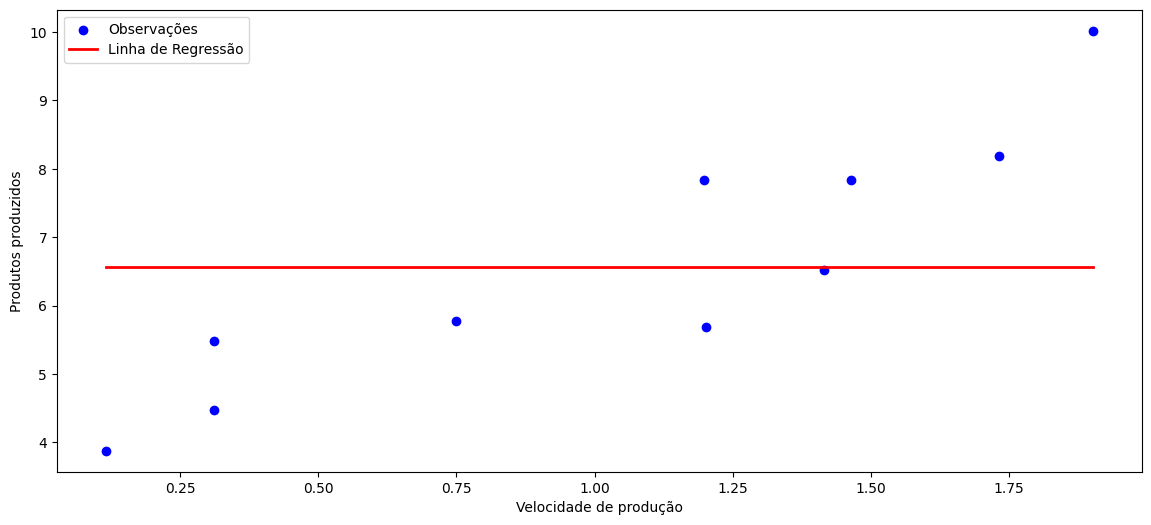

In [3]:
# Primeiro modelo: calcula-se a média dos valores de y
y_mean = np.mean(y)
print(f"Médias dos valores de produção é {y_mean}")

# Repetindo esse valor para cada valor de X, temos um vetor com a média
# y_pred é o valor predito para os valores X, utilizando um modelo que retoran a média dos valores
y_pred = np.array([y_mean for _ in range(len(X))])

# Plotando no gráfico
fig, axs = plt.subplots(1, 1, figsize=(14, 6))
# Plota os pontos
axs.scatter(X,y, color='blue', label='Observações')
# Plota o modelo
axs.plot(X, y_pred, color='red',linewidth=2, label='Linha de Regressão')
# Adiciona a legenda
plt.legend()
# Adiciona rótulos dos eixos
plt.xlabel("Velocidade de produção")
plt.ylabel("Produtos produzidos")
plt.show()

Passo 4: Encontrando a soma do quadrado dos resíduos

1. Para cada ponto (azul) é verificado então sua distância ao modelo (vermelho).
2. Eleva-se ao quadrado cada uma dessas distâncias (diferenças)
3. Soma-se esses quadrado das diferenças

In [4]:
# Distância ponto ao modelo
residuais = y_pred - y

# Residuais ao quadrado
residuais_sq = np.power(residuais, 2)

# Soma do quadrado dos resíduos
soma_residuos_sq = np.sum(residuais_sq)

print(f"Soma do quadrado dos resíduos (SSR): {soma_residuos_sq.item():.2f}")

Soma do quadrado dos resíduos (SSR): 319.06


Para ilustrar o andamento, plotam-se as linhas de diferença (laranja) entre o valor real (pontos em azul) e o valor que seria no modelo (linha em vermelho).


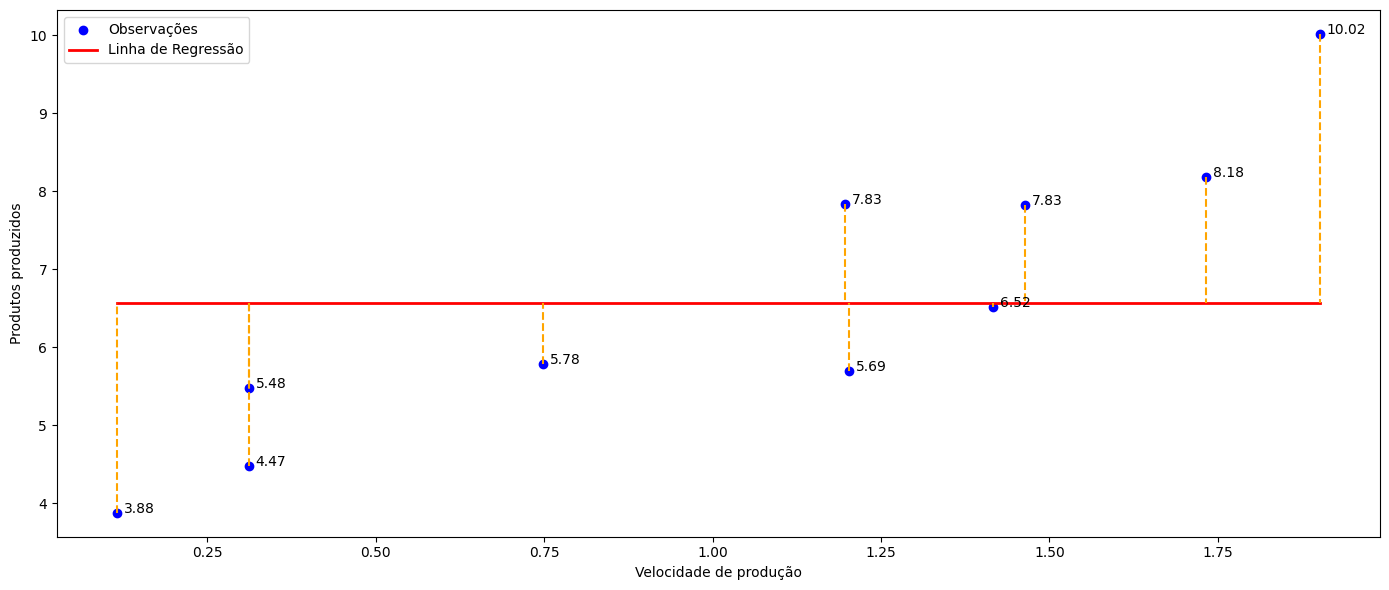

In [5]:
# Plotando no gráfico
fig, axs = plt.subplots(1, 1, figsize=(14, 6))
# Plota os pontos
axs.scatter(X,y, color='blue', label='Observações')
# Plota o modelo
axs.plot(X, y_pred, color='red',linewidth=2, label='Linha de Regressão')

# Plota as distâncias entre pontos e modelo
for i in range(len(X)):
  # Plota as linhas das distâncias em laranja
  axs.plot([X[i], X[i]], [y[i], np.array([y_pred[i]])], color='orange', linestyle='dashed')
  # Adiociona o rótulo do valor observado
  axs.text(x= X[i]+.01, y= y[i], s=str(np.round([*y[i]][0],2)))

# Adiciona a legenda
plt.legend()
# Adiciona rótulos dos eixos
plt.xlabel("Velocidade de produção")
plt.ylabel("Produtos produzidos")
plt.tight_layout()
plt.show()

Passo 5: Testa-se um novo modelo (gira a reta vermelha) e e verifica-se o SSR (soma do quadrado dos resíduos).

Um novo modelo poderia ser: \
$ y = 4 + 1.5 * X $

Então aplica-se o Passo 4 novamente.

In [6]:
# Novo modelo
y_pred = 4 + 1.5 * X

# Distância ponto ao modelo
residuais = y_pred - y

# Residuais ao quadrado
residuais_sq = np.power(residuais, 2)

# Soma do quadrado dos resíduos
soma_residuos_sq = sum(residuais_sq)

print(f"Soma do quadrado dos resíduos (SSR): {soma_residuos_sq.item():.2f}")

Soma do quadrado dos resíduos (SSR): 21.08


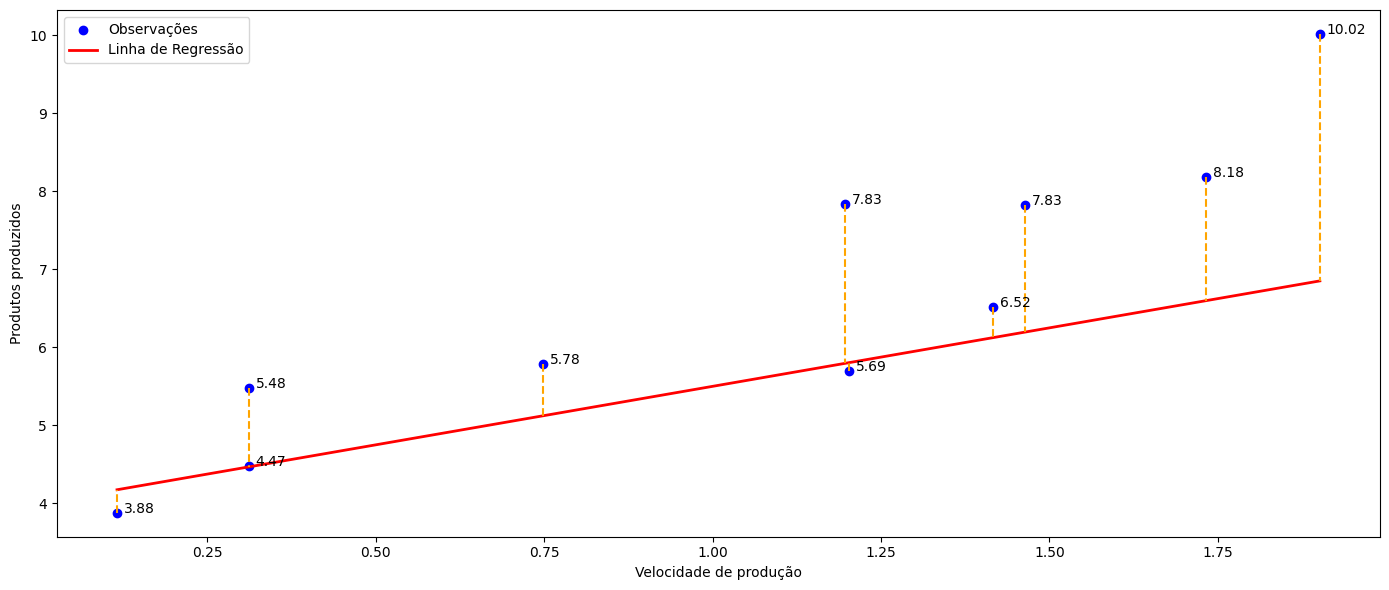

In [7]:
# Plotando no gráfico
fig, axs = plt.subplots(1, 1, figsize=(14, 6))
# Plota os pontos
axs.scatter(X,y, color='blue', label='Observações')
# Plota o modelo
axs.plot(X, y_pred, color='red',linewidth=2, label='Linha de Regressão')

# Plota as distâncias entre pontos e modelo
for i in range(len(X)):
    # Plota as linhas das distâncias
    axs.plot([X[i], X[i]], [y[i], y_pred[i]], color='orange', linestyle='dashed')
    # Adiociona o rótulo do valor observado
    axs.text(x= X[i]+.01, y= y[i], s=str(np.round([*y[i]][0],2)))

# Adiciona a legenda
plt.legend()
# Adiciona rótulos dos eixos
plt.xlabel("Velocidade de produção")
plt.ylabel("Produtos produzidos")
plt.tight_layout()
plt.show()

Na primeira iteração foi obtido SSR de 319.06.

Na segunda iteração foi obtido valor de SSR de 21.08, portanto o segundo modelo é melhor que o primeiro.

Esse processo de teste de modelos se repete até que se encontre o valor mínimo do SSR.

O processo de otimização que identifica o menor SSR chama-se **Método dos mínimos quadrados**

### Regressão com uso do sklearn

Aqui será abordado o emprego direto de modelos de regressão utilizando a biblioteca sklearn.

Esses modelos são de simples implementação, porém é necessario o entendimento de seu funcionamento, o ajuste de parâmetros, portanto a documentação deve ser sempre consultada.

Serão abordados os algoritmos: regressão linear, regressão ridge, árvores de decisão e redes neurais recorrentes.

### Criação do dataset para treino dos modelos

O conjunto de dados Diabetes disponível através do `load_diabetes()` do Scikit-learn é um conjunto de dados padrão, frequentemente utilizado para fins de aprendizado e demonstração em tarefas de machine learning. Ele contém informações sobre pacientes com diabetes, incluindo diversas características médicas como idade, sexo, índice de massa corporal (IMC), pressão arterial, níveis de glicose, etc.

Suas principais caractrísticas são:

- **Dados reais**: Os dados são provenientes de um estudo real sobre diabetes, o que o torna um conjunto de dados realista para testar algoritmos de aprendizado de máquina.
- **Variedade de features**: O dataset possui um número considerável de features, o que permite explorar diferentes técnicas de seleção e engenharia de features.
- **Target**: O objetivo (target) é uma medida quantitativa da progressão da doença, o que o torna um problema de regressão.


In [8]:
# Importação da biblioteca
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

# Carregar um conjunto de dados de exemplo
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
# Em X ficam os dados de características que serão os preditores do progresso da doença
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
# Em y, ficam os valroes de progresso da doença
y = diabetes.target

# Explicação do dataset
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [9]:
print(f"Versão do tensorflow: {tf.__version__}")

Versão do tensorflow: 2.20.0


In [10]:
# Para ilustrar melhor cada modelo, será utilizado apenas a característica de IMC (bmi)
# Nesse caso, estará sendo utilizado os dados de IMC para treinar um modelo que,
# com base apenas no valor do IMC consiga predizer o valor da progressão da doença
col = 'bmi'

# Dividir os dados em treino (80%) e teste (20%)
# utilização do random_state para manter a reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(X[col].to_numpy(), y, test_size=0.2, random_state=42)

# Ordena os dados para facilitar a plotagem
# Coloca X_test e y_test em uma tupla e ordena pela X_test
z = sorted(zip(X_test,y_test))
# "Descompacta" a lista ordenada em X_test e y_test
X_test,y_test = zip(*z)
# Transforma a tupla de valores X-test e y_tes em um array.
X_test = np.array(X_test)
y_test = np.array(y_test)

#### Função para relatório

Para evitar repetição foi definida uma função para imprimir um relatório de performance do modelo.

O relatório consta de 2 partes: Gráfico e Métricas.

**Gráfico**:
- No eixo x tem-se os valores da característica, no caso proposto bmi ou IMC.
- No eixo y, tem-se os valores da progressão da doença.
- Os pontos pretos correspondem os dados de Teste
- A linha colorida representa o modelo ajustado aos dados de Teste

**Métricas**: Faz a comparação das métricas R², MSE e MAE de performance do modelo entre os conjuntos de Treino e Teste.

In [11]:
def relatorio(X_test, y_test, y_train, y_pred_model, y_train_model, modelo, col, color_model):
  # Plot outputs
  plt.scatter(X_test, y_test, color="black")
  plt.plot(X_test, y_pred_model, color=color_model, linewidth=3)
  plt.xticks(())
  plt.yticks(())
  plt.title(f"{modelo} treinado com dados apenas de {col}")
  plt.xlabel(col)
  plt.ylabel("Progressão da doença")
  plt.show()

  # Avaliação das Métricas
  print(f"{modelo} - R²  - Treino {r2_score(y_train, y_train_model):.4f} - Teste {r2_score(y_test, y_pred_model):.4f}")
  print(f"{modelo} - MSE - Treino {mean_squared_error(y_train, y_train_model):.4f} - Teste {mean_squared_error(y_test, y_pred_model):.4f}")
  print(f"{modelo} - MAE - Treino {mean_absolute_error(y_train, y_train_model):.4f} - Teste {mean_absolute_error(y_test, y_pred_model):.4f}")

### Regressão Linear

Utilizando a biblioteca do sklearn, abaixo é treinado um modelo de regressão linear com base no valores de treino do IMC `X_train` e de progressão da doença `y_train`.

São obtidos os valores preditos para o `X_test` e guardado em `y_pred_lin`.

São obtidos os valores preditos para o `X_train` e guardado em `y_train_lin`.

São verificadas as métricas de R², MSE e MAE para os conjuntos de Treino e Teste.

In [12]:
# Modelo de Regressão Linear
lin_reg = LinearRegression()
# Treino do modelo
lin_reg.fit(X_train.reshape(-1, 1), y_train)
# Valores da predição com base nos dados de Teste
y_pred_lin = lin_reg.predict(X_test.reshape(-1, 1))
# Valores da predição com base nos dados de Treino
y_train_lin = lin_reg.predict(X_train.reshape(-1, 1))

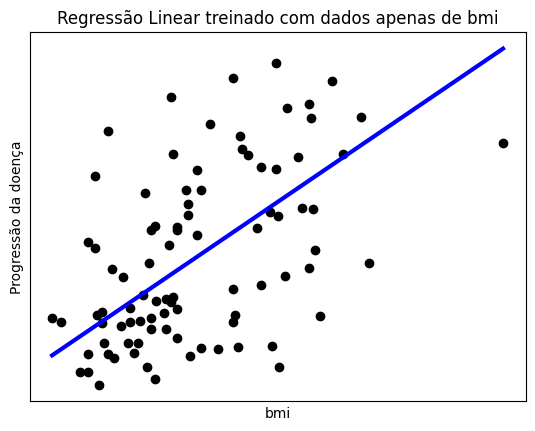

Regressão Linear - R²  - Treino 0.3657 - Teste 0.2334
Regressão Linear - MSE - Treino 3854.1127 - Teste 4061.8259
Regressão Linear - MAE - Treino 51.3797 - Teste 52.2600


In [13]:
# Imprime o relatório do modelo
modelo = 'Regressão Linear'
color_model = 'blue'
relatorio(X_test, y_test, y_train, y_pred_lin, y_train_lin, modelo, col, color_model)

### Regressão Ridge

Utilizando a biblioteca do sklearn, abaixo é treinado um modelo de regressão ridge com base no valores de treino do IMC `X_train` e de progressão da doença `y_train`.

São obtidos os valores preditos para o `X_test` e guardado em `y_pred_ridge`.

São obtidos os valores preditos para o `X_train` e guardado em `y_train_ridge`.

São verificadas as métricas de R², MSE e MAE para os conjuntos de Treino e Teste.

In [14]:
# Modelo de Regressão Ridge
ridge_reg = Ridge(alpha=1.0)
# Treino do modelo
ridge_reg.fit(X_train.reshape(-1, 1), y_train)
# Valores da predição com base nos dados de Teste
y_pred_ridge = ridge_reg.predict(X_test.reshape(-1, 1))
# Valores da predição com base nos dados de Treino
y_train_ridge = ridge_reg.predict(X_train.reshape(-1, 1))

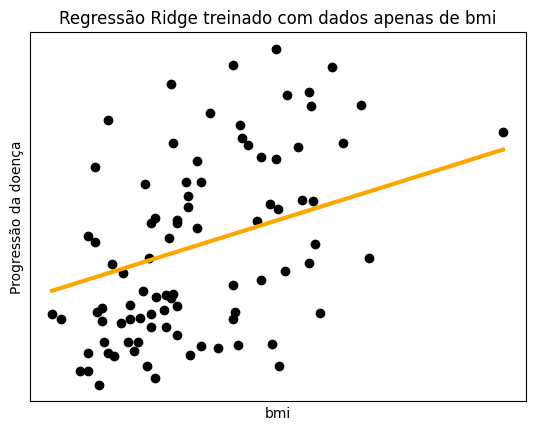

Regressão Ridge - R²  - Treino 0.2512 - Teste 0.2079
Regressão Ridge - MSE - Treino 4550.2502 - Teste 4196.6518
Regressão Ridge - MAE - Treino 57.7377 - Teste 55.9570


In [15]:
# Imprime o relatório do modelo
modelo = 'Regressão Ridge'
color_model = 'orange'
relatorio(X_test, y_test, y_train, y_pred_ridge, y_train_ridge, modelo, col, color_model)

### Árvore de Regressão

Utilizando a biblioteca do sklearn, abaixo é treinado um modelo de regressão ridge com base no valores de treino do IMC `X_train` e de progressão da doença `y_train`.

São obtidos os valores preditos para o `X_test` e guardado em `y_pred_tree`.

São obtidos os valores preditos para o `X_train` e guardado em `y_train_tree`.

São verificadas as métricas de R², MSE e MAE para os conjuntos de Treino e Teste.

In [16]:
# Modelo de Árvore de Regressão
tree_reg = DecisionTreeRegressor(random_state=42)
# Treino do modelo
tree_reg.fit(X_train.reshape(-1, 1), y_train)
# Valores da predição com base nos dados de Teste
y_pred_tree = tree_reg.predict(X_test.reshape(-1, 1))
# Valores da predição com base nos dados de Treino
y_train_tree = tree_reg.predict(X_train.reshape(-1, 1))

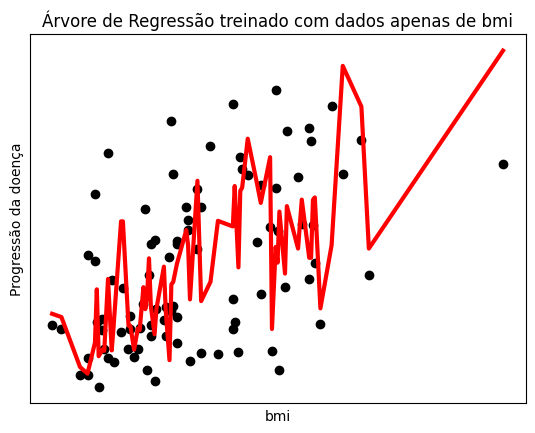

Árvore de Regressão - R²  - Treino 0.6175 - Teste 0.1560
Árvore de Regressão - MSE - Treino 2324.3150 - Teste 4471.5940
Árvore de Regressão - MAE - Treino 36.3725 - Teste 52.3906


In [17]:
# Imprime o relatório do modelo
modelo = 'Árvore de Regressão'
color_model = 'red'
relatorio(X_test, y_test, y_train, y_pred_tree, y_train_tree, modelo, col, color_model)

### Redes Neurais Recorrentes (RNN)

Utilizando a biblioteca do sklearn, abaixo é treinado um modelo de regressão ridge com base no valores de treino do IMC `X_train` e de progressão da doença `y_train`.

A RNN necessita de uma formatação adicional nos vetores, portanto é realizado essa adaptação transformando `X_train` de dimensão (353,) em `X_train_rnn` de dimensão (353,1,1). De forma análoga é transformado `X_test` em `X_test_rnn`.

São obtidos os valores preditos para o `X_test_rnn` e guardado em `y_pred_lin`.

São obtidos os valores preditos para o `X_train_rnn` e guardado em `y_train_lin`.

In [19]:
# Preparação dos dados para RNN
X_train_rnn = X_train.reshape((X_train.shape[0], 1, 1))
X_test_rnn = X_test.reshape((X_test.shape[0], 1, 1))

# Cria o Modelo de RNN empilhando diversas camadas
# Esta arquitetura cria uma rede neural recorrente com duas camadas RNN,
# seguida por duas camadas densas para processamento não linear
# e uma camada de saída para a predição.
model = Sequential([
    SimpleRNN(64, activation='tanh', return_sequences=True, input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    SimpleRNN(64, activation='tanh'),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')

# Treinamento
model.fit(X_train_rnn, y_train, epochs=500, verbose=0)

# Previsões
y_pred_rnn = model.predict(X_test_rnn)
y_train_rnn = model.predict(X_train_rnn)

C:\Users\Pc Gamer\PycharmProjects\pos-NLP\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 


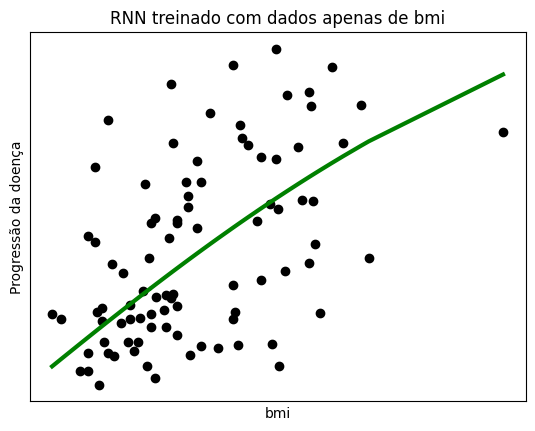

RNN - R²  - Treino 0.3591 - Teste 0.2362
RNN - MSE - Treino 3894.2691 - Teste 4046.6139
RNN - MAE - Treino 51.5595 - Teste 51.7636


In [20]:
# Imprime o relatório do modelo
modelo = 'RNN'
color_model = 'green'
relatorio(X_test, y_test, y_train, y_pred_rnn, y_train_rnn, modelo, col, color_model)

## Conclusões

Foram testados 4 modelos distintos, sendo: Regressão Linear, Regressão Ridge, Árvore de Regressão e uma RNN.

Para cada modelo foram verificados as métricas para os conjuntos de Teste e Treino, bem como foi apresentado um gráfico do modelo ajustado ao conjunto de Teste.


### Análise Crítica dos Resultados de Desempenho

A análise dos resultados de desempenho dos modelos de regressão linear, regressão Ridge, árvore de regressão e redes neurais recorrentes (RNN) revela importantes insights sobre o comportamento de cada modelo e sua adequação ao conjunto de dados. Abaixo, são discutidos aspectos relacionados ao desempenho, possíveis problemas de overfitting e a escolha do melhor modelo a ser aplicado.


   - A **regressão linear** apresenta um desempenho modesto, com uma redução significativa do R² no conjunto de teste, indicando que o modelo tem uma capacidade limitada de generalização. A proximidade entre os erros absolutos médios (MAE) de treino e teste sugere que o modelo não está superajustado (overfitted), mas também não é suficientemente robusto para capturar toda a variabilidade dos dados.

   - A **regressão Ridge**, uma variação regularizada da regressão linear, tem um desempenho ainda mais modesto, com valores de R² mais baixos tanto para treino quanto para teste. O maior valor de MSE no treino, comparado ao MSE do teste, sugere que a regularização pode estar penalizando excessivamente os coeficientes, levando a um underfitting.

   - A **árvore de regressão** apresenta um alto R² no conjunto de treino, mas um desempenho significativamente pior no teste, com uma queda abrupta no R² e um aumento no MSE. Isso é um forte indicador de overfitting, onde o modelo se ajusta muito bem aos dados de treino, mas não generaliza bem para novos dados.

   - A **RNN** apresenta valores de R² e MSE próximos tanto no treino quanto no teste. Isso é um indicador de que não há overfitting. Comparando graficamente a árvore de decisão e RNN, fica claro a questão do overfitting na árvore de decisão. A RNN mostra um desempenho muito semelhante ao da regressão linear no treino porém com um custo computacional muito mais elevado. Isso decorre principalmente porque no caso apresentado, o problema com apenas uma característica (bmi), não apresenta grandes dificuldades para a Regressão Linear, a RNN provavelmente obteria melhores resultados se todas as características do dataset fossem utilizadas.


Referências Bibliográficas:
* Géron, A. (2019). Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow: Concepts, Tools, and Techniques to Build Intelligent Systems. O'Reilly Media.
* McKinney, W. (2017). Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython. O'Reilly Media.
* Hastie, T., Tibshirani, R., & Friedman, J. (2009). The Elements of Statistical Learning: Data Mining, Inference, and Prediction. Springer Series in Statistics.
